# Cyclistic Bike-Share Analysis
## How do annual members and casual riders use Cyclistic bikes differently?

**Tools:** Python, pandas, matplotlib, SQLite  
**Data:** Divvy trip data 2019 Q1 & 2020 Q1 (791,746 rides after cleaning)  
**Business question:** Identify behavioural differences between casual riders and annual members to inform a marketing strategy aimed at converting casuals to members.

---
### Step 1: Load Data
Data is loaded directly from `cyclistic.db`, a SQLite database containing the cleaned `all_trips` view built in SQL. This view combines both years, standardises column names, removes invalid rides (negative durations, rides under 1 minute, rides over 24 hours, and test stations), and recodes `Subscriber/Customer` to `member/casual`.

In [1]:
# Imports & load data
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Connect to database and load clean data
con = sqlite3.connect('cyclistic.db')
df = pd.read_sql('SELECT * FROM all_trips', con)
con.close()

print(f'Rows loaded: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head()

DatabaseError: Execution failed on sql 'SELECT * FROM all_trips': no such table: all_trips

### Step 2: Descriptive Statistics
Summary statistics comparing ride behaviour between members and casual riders. Note that median is used alongside mean because ride length data is right-skewed. A small number of very long rides pull the mean upward, making the median a more representative measure of typical ride behaviour.

In [ ]:
# Descriptive statistics
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at']   = pd.to_datetime(df['ended_at'])

print('=== Ride Length Stats by User Type (minutes) ===')
print(df.groupby('member_casual')['ride_length_min'].agg(
    count='count',
    mean='mean',
    median='median',
    max='max'
).round(1))

print('\n=== Ride Share % ===')
print(df['member_casual'].value_counts(normalize=True).mul(100).round(1))

=== Ride Length Stats by User Type (minutes) ===
                count  mean  median       max
member_casual                                
casual          71433  85.1    22.1  177200.4
member         720313  13.3     8.5  101607.1

=== Ride Share % ===
member_casual
member    91.0
casual     9.0
Name: proportion, dtype: float64


### Step 3: Rides by Day of Week
Examining which days each rider type is most active reveals a clear pattern: members ride predominantly on weekdays while casual riders are more active on weekends. This suggests members use bikes for commuting while casuals use them for leisure.

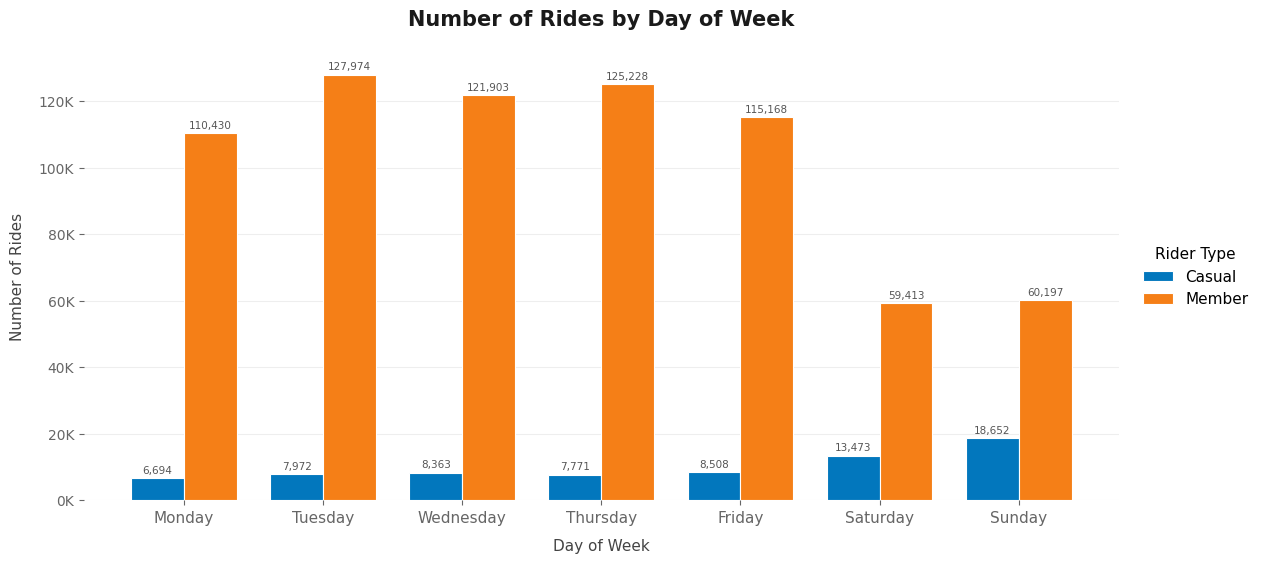

In [ ]:
# Rides by day of week
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
COLORS = {'member': '#F57F17', 'casual': '#0277BD'}

day = df.groupby(['member_casual','day_name']).size().reset_index(name='num_rides')
day['day_name'] = pd.Categorical(day['day_name'], categories=DAY_ORDER, ordered=True)
day = day.sort_values(['member_casual','day_name'])

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

width = 0.38
x = range(len(DAY_ORDER))

for i, user in enumerate(['casual','member']):
    subset = day[day['member_casual']==user].set_index('day_name')
    counts = [subset.loc[d,'num_rides'] if d in subset.index else 0 for d in DAY_ORDER]
    bars = ax.bar([xi+i*width for xi in x], counts, width=width,
                  label=user.capitalize(), color=COLORS[user],
                  edgecolor='white', linewidth=0.8, zorder=3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
                f'{count:,.0f}', ha='center', va='bottom',
                fontsize=7.5, color='#555555', fontweight='500')

ax.set_xticks([xi+width/2 for xi in x])
ax.set_xticklabels(DAY_ORDER, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v/1000)}K'))
ax.set_title('Number of Rides by Day of Week', fontsize=15,
             fontweight='bold', pad=20, color='#1a1a1a')
ax.set_xlabel('Day of Week', fontsize=11, labelpad=10, color='#444444')
ax.set_ylabel('Number of Rides', fontsize=11, labelpad=10, color='#444444')
ax.tick_params(colors='#666666')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=11, frameon=False, title='Rider Type', title_fontsize=11,
          loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(pad=2)
plt.savefig('charts/chart1_rides_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4: Median Ride Length by Day of Week
Casual riders consistently take longer trips than members across every day of the week, roughly 2.5x longer. The relatively flat member line suggests consistent short-distance commuting behaviour, while the casual line peaks on weekends indicating longer recreational rides.

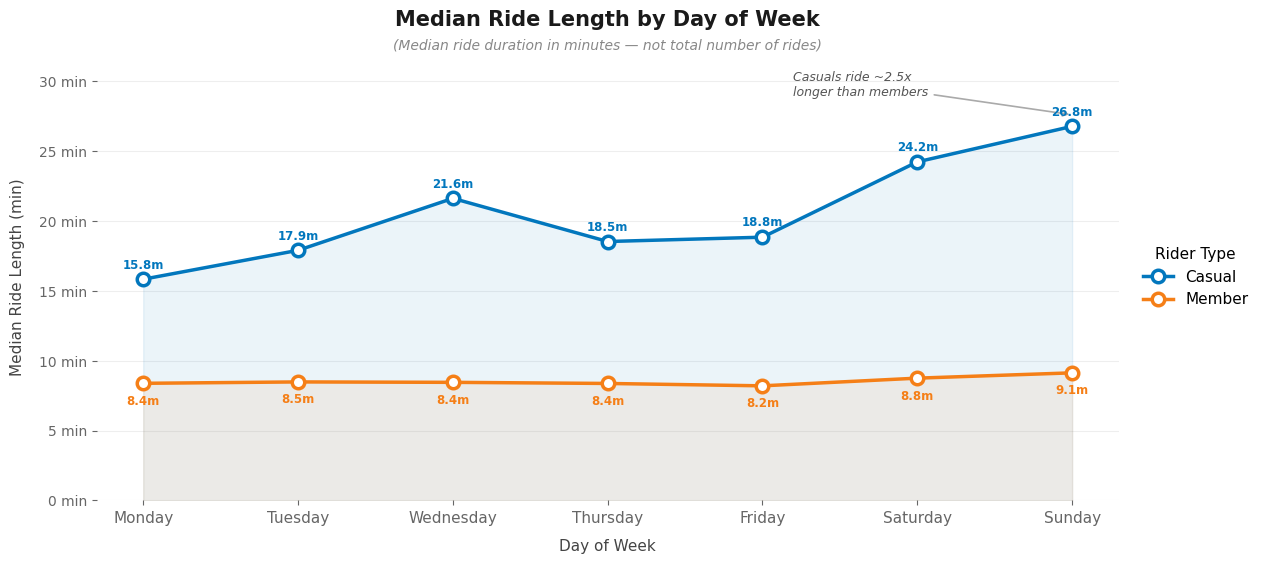

In [ ]:
# Median ride length by day of week
day_med = df.groupby(['member_casual','day_name'])['ride_length_min'].median().reset_index()
day_med['day_name'] = pd.Categorical(day_med['day_name'], categories=DAY_ORDER, ordered=True)
day_med = day_med.sort_values(['member_casual','day_name'])

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for user in ['casual', 'member']:
    subset = day_med[day_med['member_casual']==user].set_index('day_name')
    vals = [subset.loc[d,'ride_length_min'] for d in DAY_ORDER]
    ax.fill_between(range(len(DAY_ORDER)), vals, alpha=0.08, color=COLORS[user], zorder=1)
    ax.plot(range(len(DAY_ORDER)), vals, marker='o', linewidth=2.5, markersize=9,
            label=user.capitalize(), color=COLORS[user], zorder=4,
            markerfacecolor='white', markeredgewidth=2.5, markeredgecolor=COLORS[user])
    for i, v in enumerate(vals):
        offset = 0.8 if user == 'casual' else -1.5
        ax.text(i, v+offset, f'{v:.1f}m', ha='center',
                fontsize=8.5, color=COLORS[user], fontweight='600', zorder=5)

ax.set_xticks(range(len(DAY_ORDER)))
ax.set_xticklabels(DAY_ORDER, fontsize=11)
ax.set_ylim(0, 32)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v)} min'))
ax.set_title('Median Ride Length by Day of Week', fontsize=15,
             fontweight='bold', pad=20, color='#1a1a1a')
ax.text(0.5, 1.01, '(Median ride duration in minutes — not total number of rides)',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#888888', style='italic')
ax.set_xlabel('Day of Week', fontsize=11, labelpad=10, color='#444444')
ax.set_ylabel('Median Ride Length (min)', fontsize=11, labelpad=10, color='#444444')
ax.tick_params(colors='#666666')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.annotate('Casuals ride ~2.5x\nlonger than members',
            xy=(6, 27.6), xytext=(4.2, 29),
            fontsize=9, color='#555555', style='italic',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=1.2))
ax.legend(fontsize=11, frameon=False, title='Rider Type', title_fontsize=11,
          loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(pad=2)
plt.savefig('charts/chart2_ride_length_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 5: Rides by Hour of Day
The hourly distribution is the clearest evidence of the commuter vs leisure divide. Members show two sharp peaks at 08:00 and 17:00, typical morning and evening commute times. Casual riders show a gradual build peaking around 14:00-15:00 with no commute spikes, consistent with recreational use.

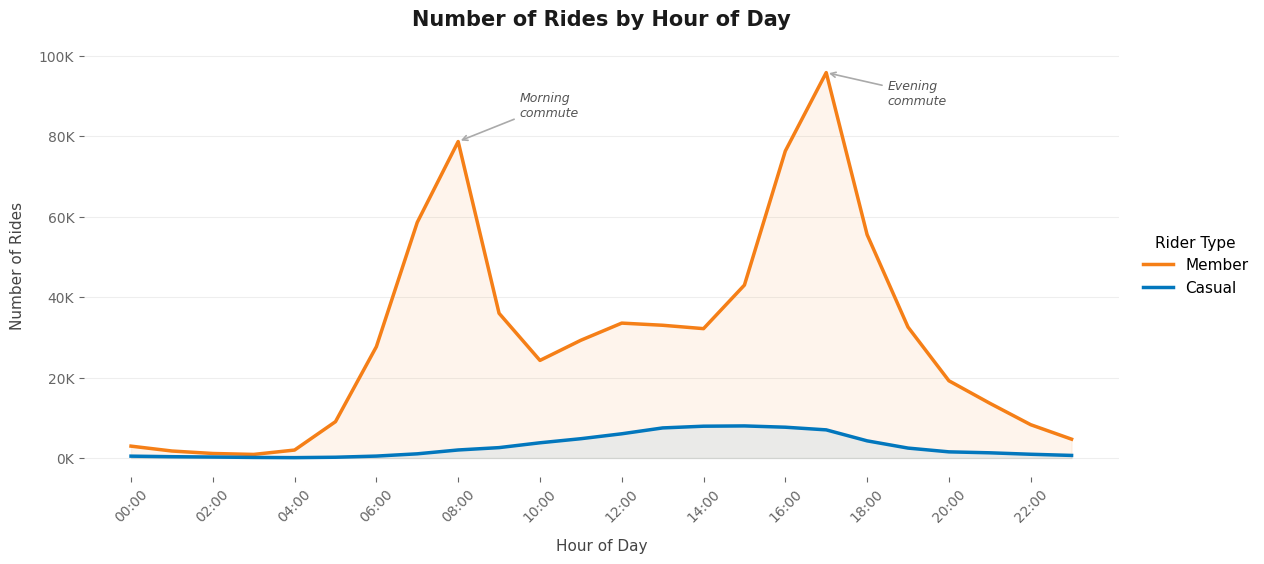

In [ ]:
# Rides by hour of day
df['hour'] = df['started_at'].dt.hour
hour = df.groupby(['member_casual','hour']).size().reset_index(name='num_rides')

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

member_vals = [hour[(hour['member_casual']=='member') & (hour['hour']==h)]['num_rides'].values[0]
               if h in hour[hour['member_casual']=='member']['hour'].values else 0 for h in range(24)]
casual_vals = [hour[(hour['member_casual']=='casual') & (hour['hour']==h)]['num_rides'].values[0]
               if h in hour[hour['member_casual']=='casual']['hour'].values else 0 for h in range(24)]

for user, vals in [('member', member_vals), ('casual', casual_vals)]:
    ax.fill_between(range(24), vals, alpha=0.08, color=COLORS[user], zorder=1)
    ax.plot(range(24), vals, linewidth=2.5, label=user.capitalize(),
            color=COLORS[user], zorder=3)

ax.annotate('Morning\ncommute', xy=(8, member_vals[8]), xytext=(9.5, 85000),
            fontsize=9, color='#555555', style='italic',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=1.2))
ax.annotate('Evening\ncommute', xy=(17, member_vals[17]), xytext=(18.5, 88000),
            fontsize=9, color='#555555', style='italic',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=1.2))

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], fontsize=10, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v/1000)}K'))
ax.set_title('Number of Rides by Hour of Day', fontsize=15,
             fontweight='bold', pad=20, color='#1a1a1a')
ax.set_xlabel('Hour of Day', fontsize=11, labelpad=10, color='#444444')
ax.set_ylabel('Number of Rides', fontsize=11, labelpad=10, color='#444444')
ax.tick_params(colors='#666666')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=11, frameon=False, title='Rider Type', title_fontsize=11,
          loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(pad=2)
plt.savefig('charts/chart3_rides_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Year-over-Year Comparison (2019 Q1 vs. 2020 Q1)
Comparing the same quarter across two years reveals strong growth in both segments. Notably, casual ridership more than doubled (+109%) while member ridership grew by 11%. This suggests growing awareness of the service among casual users, a promising signal for membership conversion campaigns.

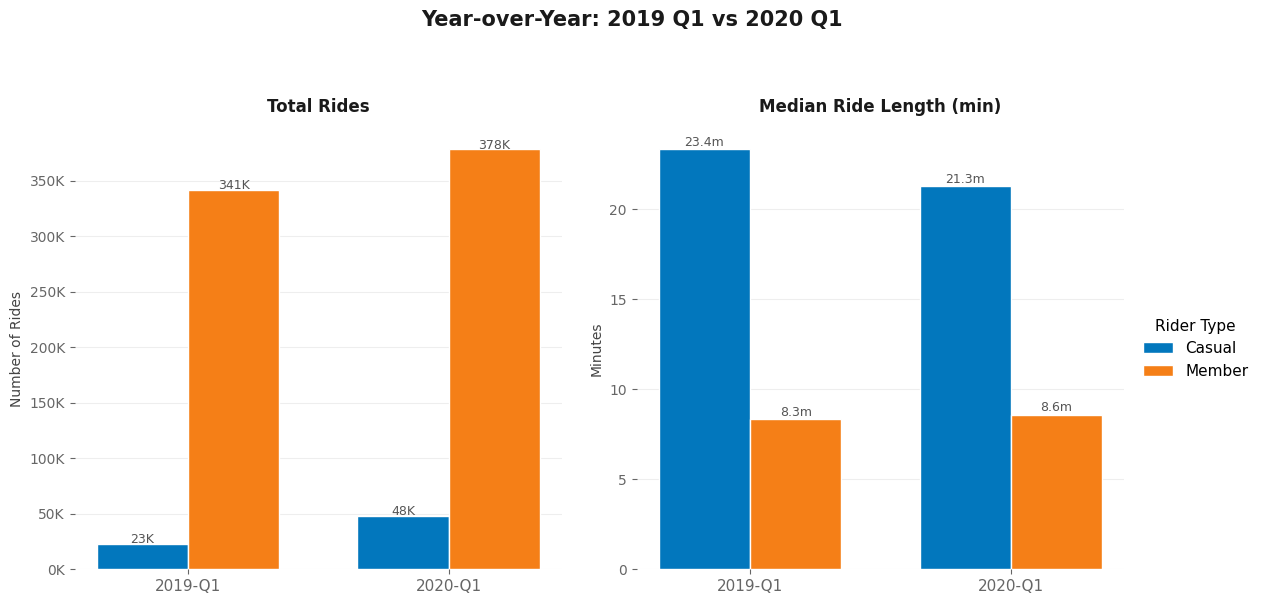

In [ ]:
# Year over year comparison
yoy = df.groupby(['source_year','member_casual']).agg(
    num_rides=('ride_length_min','count'),
    median_min=('ride_length_min','median')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Year-over-Year: 2019 Q1 vs 2020 Q1', fontsize=15,
             fontweight='bold', color='#1a1a1a', y=1.02)

years = ['2019-Q1','2020-Q1']

for ax, metric, title, ylabel in zip(
    axes,
    ['num_rides','median_min'],
    ['Total Rides','Median Ride Length (min)'],
    ['Number of Rides','Minutes']
):
    ax.set_facecolor('white')
    for i, user in enumerate(['casual','member']):
        vals = [yoy[(yoy['source_year']==y) & (yoy['member_casual']==user)][metric].values[0]
                for y in years]
        bars = ax.bar([x+i*0.35 for x in range(len(years))], vals, width=0.35,
                      label=user.capitalize(), color=COLORS[user],
                      edgecolor='white', zorder=3)
        for bar, v in zip(bars, vals):
            label = f'{int(v/1000)}K' if metric=='num_rides' else f'{v:.1f}m'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500 if metric=='num_rides' else bar.get_height()+0.2,
                    label, ha='center', fontsize=9, color='#555555', fontweight='500')
    ax.set_xticks([x+0.175 for x in range(len(years))])
    ax.set_xticklabels(years, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1a1a1a', pad=12)
    ax.set_ylabel(ylabel, fontsize=10, color='#444444')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#666666')
    if metric == 'num_rides':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v/1000)}K'))

axes[1].legend(fontsize=11, frameon=False, title='Rider Type', title_fontsize=11,
               loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(pad=2)
plt.savefig('charts/chart4_year_over_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 7: Top Start Stations by Rider Type
Identifying the most popular departure stations for each rider type helps pinpoint where to place physical marketing materials such as posters, QR codes, and promotional staff. Stations popular with casual riders but not members represent the highest-opportunity locations for conversion campaigns.

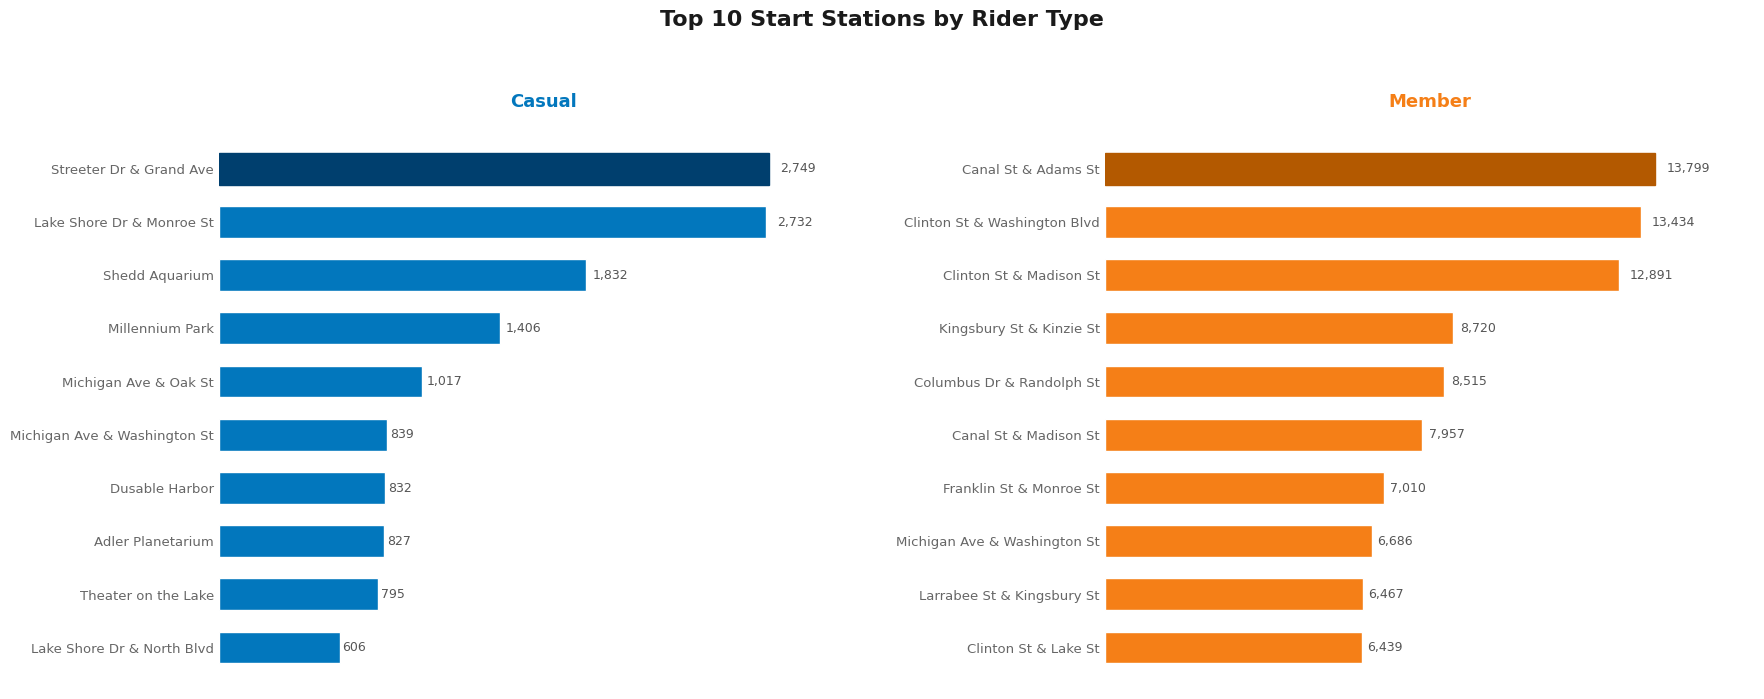

In [ ]:
# Top 10 start stations per rider type
con = sqlite3.connect('cyclistic.db')
stations = pd.read_sql('''
    SELECT member_casual, start_station_name, COUNT(*) AS num_rides
    FROM all_trips
    WHERE start_station_name IS NOT NULL
    AND start_station_name NOT LIKE "%HQ%"
    AND start_station_name NOT LIKE "%TEST%"
    AND start_station_name NOT LIKE "%DIVVY%"
    GROUP BY member_casual, start_station_name
    ORDER BY member_casual, num_rides DESC
''', con)
con.close()

top = stations.groupby('member_casual').head(10).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Top 10 Start Stations by Rider Type', fontsize=16,
             fontweight='bold', color='#1a1a1a', y=1.01)

for ax, user in zip(axes, ['casual', 'member']):
    subset = top[top['member_casual']==user].sort_values('num_rides').iloc[-10:]
    color = COLORS[user]
    ax.set_facecolor('white')
    bars = ax.barh(subset['start_station_name'], subset['num_rides'],
                   color=color, edgecolor='white', height=0.6, zorder=3)
    for bar, v in zip(bars, subset['num_rides']):
        ax.text(bar.get_width() + bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9,
                color='#555555', fontweight='500')
    bars[-1].set_color('#B35900' if user=='member' else '#003f6e')
    ax.set_title(user.capitalize(), fontsize=13, fontweight='bold',
                 color=color, pad=15)
    ax.set_xlabel('Number of Rides', fontsize=10, color='#444444', labelpad=10)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#666666', labelsize=9.5)
    ax.tick_params(axis='y', length=0)
    ax.set_xlim(0, subset['num_rides'].max() * 1.18)
    ax.xaxis.set_visible(False)
plt.tight_layout(pad=2)
plt.savefig('charts/chart5_top_stations.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 8: Export Summary
A consolidated summary of all key metrics across the analysis, exported as a CSV for reporting and sharing with stakeholders.

In [ ]:
# Export summary to multi-sheet Excel
import openpyxl

# 1. Overall stats
overall = df.groupby('member_casual').agg(
    total_rides=('ride_length_min','count'),
    mean_ride_min=('ride_length_min','mean'),
    median_ride_min=('ride_length_min','median'),
    max_ride_min=('ride_length_min','max'),
    pct_of_total=('ride_length_min', lambda x: round(len(x)/len(df)*100, 1))
).round(1).reset_index()

# 2. Rides by day
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = df.groupby(['member_casual','day_name']).size().reset_index(name='num_rides')
by_day['day_name'] = pd.Categorical(by_day['day_name'], categories=DAY_ORDER, ordered=True)
by_day = by_day.sort_values(['member_casual','day_name']).reset_index(drop=True)

# 3. Rides by hour
by_hour = df.groupby(['member_casual','hour']).size().reset_index(name='num_rides')
by_hour = by_hour.sort_values(['member_casual','hour']).reset_index(drop=True)

# 4. Median ride length by day
by_day_med = df.groupby(['member_casual','day_name'])['ride_length_min'].median().reset_index()
by_day_med.columns = ['member_casual','day_name','median_ride_min']
by_day_med['day_name'] = pd.Categorical(by_day_med['day_name'], categories=DAY_ORDER, ordered=True)
by_day_med = by_day_med.sort_values(['member_casual','day_name']).reset_index(drop=True)
by_day_med['median_ride_min'] = by_day_med['median_ride_min'].round(1)

# 5. Top stations
con = sqlite3.connect('cyclistic.db')
top_stations = pd.read_sql('''
    SELECT member_casual, start_station_name, COUNT(*) AS num_rides
    FROM all_trips
    WHERE start_station_name IS NOT NULL
    AND start_station_name NOT LIKE "%HQ%"
    AND start_station_name NOT LIKE "%TEST%"
    AND start_station_name NOT LIKE "%DIVVY%"
    GROUP BY member_casual, start_station_name
    ORDER BY member_casual, num_rides DESC
''', con)
con.close()
top_stations = top_stations.groupby('member_casual').head(10).reset_index(drop=True)

# 6. Year over year
yoy = df.groupby(['source_year','member_casual']).agg(
    total_rides=('ride_length_min','count'),
    median_ride_min=('ride_length_min','median')
).round(1).reset_index()

# Export to Excel
with pd.ExcelWriter('cyclistic_summary.xlsx', engine='openpyxl') as writer:
    overall.to_excel(writer, sheet_name='Overall Stats', index=False)
    by_day.to_excel(writer, sheet_name='Rides by Day', index=False)
    by_day_med.to_excel(writer, sheet_name='Ride Length by Day', index=False)
    by_hour.to_excel(writer, sheet_name='Rides by Hour', index=False)
    top_stations.to_excel(writer, sheet_name='Top Stations', index=False)
    yoy.to_excel(writer, sheet_name='Year over Year', index=False)

print('✅ Saved: cyclistic_summary.xlsx')
print('   Sheets: Overall Stats, Rides by Day, Ride Length by Day,')
print('           Rides by Hour, Top Stations, Year over Year')

✅ Saved: cyclistic_summary.xlsx
   Sheets: Overall Stats, Rides by Day, Ride Length by Day,
           Rides by Hour, Top Stations, Year over Year


## Key Findings

| Finding | Members | Casual Riders |
|---|---|---|
| Ride volume | 91% of all rides | 9% of all rides |
| Mean ride length | 13.3 min | 85.1 min |
| Median ride length | 8.5 min | 22.1 min |
| Busiest days | Tuesday–Thursday | Saturday–Sunday |
| Peak hours | 8am & 5pm (commute) | 2–3pm (leisure) |
| Top stations | Downtown office hubs | Tourist landmarks |
| YoY growth | +11% | +109% |

## Conclusions

The data tells a clear and consistent story across every dimension analysed:

**Members** use Cyclistic bikes as a commuting tool : short, frequent rides on weekdays, concentrated around downtown office and transit stations, with sharp peaks at 8am and 5pm. Their behaviour is highly predictable and routine.

**Casual riders** use Cyclistic bikes for leisure and recreation : longer rides on weekends, departing from tourist landmarks like Millennium Park, Shedd Aquarium and Lake Shore Drive, peaking in the early afternoon. Their usage is exploratory rather than routine.

## Top 3 Recommendations

**1. Weekend membership campaigns at high-traffic casual stations**
Deploy targeted promotions at the top casual stations (Streeter Dr & Grand Ave, Lake Shore Dr & Monroe St, and Millennium Park) on Saturdays and Sundays when casual ridership peaks. QR codes, posters, and on-site staff highlighting cost savings for frequent riders would reach the highest-opportunity audience at the right time and place.

**2. "Commuter conversion" digital campaign**
Casual riders already show some weekday usage, Friday in particular sees relatively higher casual activity. A targeted digital campaign (social media, email) showing the cost comparison between pay-per-ride and annual membership for someone who rides even 3-4 times per week could convert habitual casual users. The +109% YoY growth in casual riders suggests a growing, receptive audience.

**3. Seasonal campaign before peak riding season**
Q1 data shows strong casual ridership even in winter months. Launching a membership promotion in March–April (just before Chicago's peak cycling season) could capture casual riders at the moment they are most motivated to ride regularly. A limited-time discounted annual membership offered to existing casual riders before summer would create urgency and leverage the seasonal enthusiasm.

## Data Limitations
- Only Q1 data available. Seasonal patterns cannot be fully assessed
- Bike type analysis not possible. 2020 Q1 only records `docked_bike`; electric and classic bikes were introduced later in 2020
- No demographic data, age and gender available in 2019 only and partially missing
- Cannot link rides to individual users. Impossible to know if casual riders are repeat users or tourists

## Next Steps
- Obtain full-year data to analyse seasonal trends
- Analyse 2020 Q3/Q4 data for bike type preferences
- Conduct user surveys to understand barriers to membership conversion
- A/B test the recommended campaigns and measure conversion rates